# QPGP base functions

In [ ]:
import numpy as np
from numpy.random import multivariate_normal as mvnrnd
from scipy.linalg import toeplitz, solve_triangular, solve_toeplitz, cholesky, inv
from numpy.fft import fft, ifft


def QPGP_sim(n, p, w,Kappa):
    """
    Simulates a quasi-periodic Gaussian process (QPGP).

    Parameters:
    - n     : int, total length of time series
    - p     : int, periodicity parameter
    - w : float, autoregressive weight
    - Kappa  : covariance matrix

    Returns:
    - X     : np.ndarray of shape (n,), simulated QPGP series
    """

    # Number of blocks
    k = n // p

    # Preallocate X
    if n % p == 0:
        X = np.zeros(n)
        # First block ~ N(0, Kappa / (1 - w^2))
        X[:p] = mvnrnd(mean=np.zeros(p), cov=Kappa / (1 - w**2))
        for i in range(1, k):
            prev = X[(i-1)*p : i*p]
            noise = mvnrnd(mean=np.zeros(p), cov=Kappa)
            X[i*p : (i+1)*p] = w * prev + noise
    else:
        X = np.zeros((k+1)*p)
        X[:p] = mvnrnd(mean=np.zeros(p), cov=Kappa / (1 - w**2))
        for i in range(1, k+1):
            prev = X[(i-1)*p : i*p]
            noise = mvnrnd(mean=np.zeros(p), cov=Kappa)
            X[i*p : (i+1)*p] = w * prev + noise
        X = X[:n]

    return X

def logL(n, p, w, Kappa, X):
    """
    Computes the log-likelihood for block-wise Gaussian model using
    Toeplitz Cholesky factorization.

    Parameters:
    - n     : int, total length of vector X
    - p     : int, block size
    - w     : float, autoregressive coefficient
    - Kappa : np.ndarray (p x p), Toeplitz covariance matrix
    - X     : np.ndarray of shape (n,), data vector

    Returns:
    - logL  : float, computed log-likelihood
    """
    Kappa = Kappa + 1e-10 * np.eye(p)

    # Get first column of the Toeplitz matrix
    c = Kappa[:, 0]

    # Compute Toeplitz Cholesky factor: Kappa = L L^T

    L = cholesky(Kappa, lower=True)

    # Number of blocks
    k = n // p
    sum_term = 0.0

    # Loop over blocks
    for i in range(1, k):
        X_curr = X[i*p : (i+1)*p]
        X_prev = X[(i-1)*p : i*p]
        diff = X_curr - w * X_prev

        # Efficiently solve Kappa^{-1} diff
        sol = solve_toeplitz((c, c), diff)
        sum_term += diff @ sol    # Compute log-determinant from Cholesky diagonal

    logdet_Kappa = 2 * np.sum(np.log(np.diag(L)))

    # Log-likelihood (negative)
    log_likelihood = ((k - 1) * p * np.log(2 * np.pi)) / 2 + ((k - 1) * logdet_Kappa) / 2 + sum_term

    # Handle numerical issues
    if np.isnan(log_likelihood) or log_likelihood < -1e10:
        return np.inf
    else:
        return log_likelihood


def w_est(n, p, Kappa, X):
    """
    Estimates the autoregressive parameter omega.

    Parameters:
    - n     : int, number of observations
    - p     : int, block size
    - Kappa : np.ndarra
    y (p x p), covariance matrix
    - X     : np.ndarray (n,), data vector

    Returns:
    - w_est : float, estimated omega
    """
    k = n // p

    # Spectral decomposition of Kappa
    eig_vals, U = np.linalg.eigh(Kappa)
    Kappa_inv = U @ np.diag(1.0 / eig_vals) @ U.T

    # Numerator (i1i)
    i1i = 0.0
    for i in range(1, k):
        x1 = X[(i-1)*p - p : (i-1)*p] if i > 1 else X[0:p]
        x2 = X[(i)*p - p : (i)*p]
        i1i += x1.T @ Kappa_inv @ x2

    # Denominator (ii)
    ii = 0.0
    for i in range(k - 1):
        x = X[i*p : (i+1)*p]
        ii += x.T @ Kappa_inv @ x

    # If n is not divisible by p, include the remainder part
    if n % p != 0:
        Kappastar = Kappa[0:(n - k*p), 0:(n - k*p)]
        eig_vals_star, U_star = np.linalg.eigh(Kappastar)
        Kappastar_inv = U_star @ np.diag(1.0 / eig_vals_star) @ U_star.T

        xi = X[k*p - p : n - p]
        xi1 = X[k*p : n]
        nstar = xi.T @ Kappastar_inv @ xi1
        dstar = xi.T @ Kappastar_inv @ xi
    else:
        nstar = 0.0
        dstar = 0.0

    # Final omega estimate
    return (i1i + nstar) / (ii + dstar)


def Kappa_est(n, p, omega, X):
    """
    Direct translation of MATLAB Kappa_est.
    Inputs:
        n     : Number of observations
        p     : Block size
        omega : Weight parameter
        X     : Data vector (1D numpy array)
    Output:
        Kappa_est : Estimated covariance matrix (p x p)
    """
    k = n // p             # floor(n / p)
    l = n - k * p          # remainder length

    S = np.zeros((p, p))   # Initialize S matrix
    S_new = np.zeros((p, p))

    # Create Y matrix from X (reshape like MATLAB)
    Y = X[:k*p].reshape((p, k), order='F')
    if l > 0:
        last_col = np.full((p, 1), np.nan)
        last_col[:l, 0] = X[k*p:]
        Y = np.hstack((Y, last_col))

    # Difference matrix
    Y_matrix = Y[:, 1:] - omega * Y[:, :-1]

    # Loop through blocks to compute S
    for i in range(1, k):
        x_current = X[i*p : (i+1)*p]
        x_prev = X[(i-1)*p : i*p]
        residual = x_current - omega * x_prev
        S += np.outer(residual, residual)

    if n % p == 0:
        S /= (k - 1)
    else:
        S = np.zeros((p, p))

        Y_matrix1 = Y_matrix[:l, :k-1]
        Y_matrix2 = Y_matrix[l:, :k-1]

        S11 = (Y_matrix1 @ Y_matrix1.T) / (k - 1)
        S12 = (Y_matrix1 @ Y_matrix2.T) / (k - 1)
        S21 = S12.T
        S22 = (Y_matrix2 @ Y_matrix2.T) / (k - 1)

        add = np.outer(Y[:l, k], Y[:l, k])
        S11star = ((k - 1) * S11 + add) / k

        S_new[:l, :l] = S11star
        S_new[:l, l:] = S11star @ inv(S11) @ S12
        S_new[l:, :l] = S_new[:l, l:].T
        S_new[l:, l:] = S22 - S21 @ inv(S11) @ S12 \
                        + S21 @ inv(S11) @ S11star @ inv(S11) @ S12

        S = S_new

    # Enforce Toeplitz structure by averaging diagonals
    m, n_ = S.shape
    for d in range(-(m-1), n_):
        indices = [(i, i - d) for i in range(m) if 0 <= i - d < n_]
        diag_vals = [S[i, j] for i, j in indices]
        avg_val = np.mean(diag_vals)
        for i, j in indices:
            S[i, j] = avg_val

    epsilon = 1e-6
    f = np.real(fft(S[0, :]))
    f[f < 0] = 0
    f = np.abs(f)
    f = np.maximum(f, epsilon)
    v = np.real(ifft(f))

    return toeplitz(v)

def w_Kappa_est(n, p, X, max_iter=200, tol=1e-5):
    """
    Iteratively estimates omega and Kappa covariance matrix.

    Parameters:
    - n        : int, number of observations
    - p        : int, block size
    - X        : np.ndarray (n,), data vector
    - max_iter : int, max number of iterations (default 200)
    - tol      : float, convergence tolerance (default 1e-5)

    Returns:
    - result : dict with keys:
        'w'     : estimated omega
        'Kappa' : estimated covariance matrix
    """
    Kappa_hat = []
    w_hat = []
    l =[]

    Kappa_hat.append(np.eye(p))
    w_hat.append(w_est(n, p, Kappa_hat[0], X))

    for i in range(1, max_iter):
        a = Kappa_est(n, p, w_hat[i-1], X)
        Kappa_hat.append(a)
        b = w_est(n, p, Kappa_hat[i], X)
        w_hat.append(b)
        c=logL(n, p, b, a, X)
        l.append(c)
        if i > 1 and abs(l[-1] - l[-2]) < tol:
            break

    last_iter = i
    w_final = w_hat[last_iter]
    Kappa_final = Kappa_hat[last_iter]

    return {'w': w_final, 'Kappa': Kappa_final}


def par_est(n, p_search, X):
    """
    Estimate the best (p, omega, Kappa) by maximizing the log-likelihood.

    Parameters:
    - n         : int, length of data
    - p_search  : list or array of candidate p values
    - X         : (n,) numpy array of data

    Returns:
    - result: dict with keys:
        - 'p'      : estimated p
        - 'w'      : estimated omega
        - 'Kappa'  : estimated Kappa matrix (2D numpy array)
    """
    logL_vals = []

    for p in p_search:
        var = w_Kappa_est(n, p, X)
        w = var['w']
        Kappa = var['Kappa']
        logL_val = logL(n, p, w, Kappa, X)
        logL_vals.append(logL_val)

    best_idx = np.argmin(logL_vals)
    p_est = p_search[best_idx]

    final = w_Kappa_est(n, p_est, X)
    result = {
        'p': p_est,
        'w': final['w'],
        'Kappa': final['Kappa']
    }

    return result


def pred_element(n, p, w, Kappa, X):
    pred = np.zeros(n + p)
    Kappa = Kappa + 1e-10 * np.eye(p)  # Numerical stability

    for j in range(1, n + p + 1):
        if j % p != 0:
            i = j // p
            l = j - i * p
        else:
            i = j // p - 1
            l = p

        if l == 1 or i < 0:
            pred1 = w * X[(i - 1) * p + l - 1] if j > p and i - 1 >= 0 else 0
            pred2 = 0
            pred[j - 1] = pred1 + pred2
            continue

        # Valid case
        if j > p:
            pred1 = w * X[(i - 1) * p + l - 1]
            K11 = Kappa[l - 1, :l - 1].reshape(1, -1)
            K00 = Kappa[:l - 1, :l - 1]

            X_curr = X[i * p : i * p + l - 1]
            X_prev = X[(i - 1) * p : (i - 1) * p + l - 1]

            if X_curr.size == 0 or X_prev.size == 0 or K00.shape[0] == 0:
                # Skip problematic step
                pred2 = 0
            else:
                delta_X = (X_curr - w * X_prev).reshape(-1, 1)
                pred2 = (K11 @ np.linalg.inv(K00) @ delta_X).item()
        else:
            pred1 = 0
            K11 = Kappa[l - 1, :l - 1].reshape(1, -1)
            K00 = Kappa[:l - 1, :l - 1]
            X_prev = X[:l - 1]

            if X_prev.size == 0 or K00.shape[0] == 0:
                pred2 = 0
            else:
                pred2 = (K11 @ np.linalg.inv(K00) @ X_prev.reshape(-1, 1)).item()

        pred[j - 1] = pred1 + pred2

    return pred


def pred_block(n, p, w, X):
   # pred = np.zeros(p)
    pred = w*X[-p:]

    return pred


# Manipulator Simulation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Forward kinematics: joint positions including end-effector
def fk_3link_joints(theta1, theta2, theta3, l1=1.0, l2=1.0, l3=0.5):
    x0, y0 = 0.0, 0.0
    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)
    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)
    x3 = x2 + l3 * np.cos(theta1 + theta2 + theta3)
    y3 = y2 + l3 * np.sin(theta1 + theta2 + theta3)
    return [x0, x1, x2, x3], [y0, y1, y2, y3]

# End-effector position only
def fk_ee(theta1, theta2, theta3, l1=1.0, l2=1.0, l3=0.5):
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2) + l3 * np.cos(theta1 + theta2 + theta3)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2) + l3 * np.sin(theta1 + theta2 + theta3)
    return x, y


# Jacobian matrix for 3-link planar manipulator (end-effector pos wrt joint angles)
def jacobian(theta1, theta2, theta3, l1=1.0, l2=1.0, l3=0.5):
    s1 = np.sin(theta1)
    c1 = np.cos(theta1)
    s12 = np.sin(theta1 + theta2)
    c12 = np.cos(theta1 + theta2)
    s123 = np.sin(theta1 + theta2 + theta3)
    c123 = np.cos(theta1 + theta2 + theta3)

    J = np.zeros((2,3))
    J[0,0] = -l1*s1 - l2*s12 - l3*s123
    J[0,1] = -l2*s12 - l3*s123
    J[0,2] = -l3*s123
    J[1,0] =  l1*c1 + l2*c12 + l3*c123
    J[1,1] =  l2*c12 + l3*c123
    J[1,2] =  l3*c123
    return J

# Inverse kinematics approximation ignoring 3rd link orientation (same as before)
def ik_3link(x_d, y_d, l1=1.0, l2=1.0, l3=0.5):
    xe = x_d - l3
    ye = y_d
    D = (xe**2 + ye**2 - l1**2 - l2**2) / (2 * l1 * l2)
    D = np.clip(D, -1.0, 1.0)
    theta2 = np.arctan2(np.sqrt(1 - D**2), D)
    theta1 = np.arctan2(ye, xe) - np.arctan2(l2 * np.sin(theta2), l1 + l2 * np.cos(theta2))
    theta3 = 0.0
    return theta1, theta2, theta3


# Parameters

In [ ]:
# Desired trajectory 
n_points = 100
t = np.linspace(0, 2 * np.pi, n_points)
x_d = 1.5 + 0.5 * np.cos(t)
y_d = 1. + 0.5 * np.sin(t)

# Initial bias (unknown dynamics)

s = np.linspace(0, 1, n_points)
b1_s = 0.2 + 0.5*np.sin(8*np.pi*s) + 0.1*np.random.randn(len(s))
b2_s = -0.25 + 0.1*np.cos(6*np.pi*s) + 0.2*np.random.randn(len(s))
b3_s = 0.35 + 0.5*np.exp(-(s-0.04)**2/(2*0.05**2)) + 0.1*np.random.randn(len(s))

# ILC params
n_iter = 100
K = 0.25
Kp=0.3

x_ee_noise_sd = 0.00
y_ee_noise_sd = 0.00

np.random.seed(1)

# Standard ILC

In [5]:
theta1b_d = np.zeros(n_points)
theta2b_d = np.zeros(n_points)
theta3b_d = np.zeros(n_points)
for i in range(n_points):
    th1, th2, th3 = ik_3link(x_d[i], y_d[i])
    theta1b_d[i] = th1
    theta2b_d[i] = th2
    theta3b_d[i] = th3

# ----------------- Baseline ILC -----------------
baseline_errors = []
all_joints_b = []

theta1b_ff = theta1b_d.copy()
theta2b_ff = theta2b_d.copy()
theta3b_ff = theta3b_d.copy()

for it in range(n_iter):

    # Actual executed joints = feedforward + bias
    theta1b_act = theta1b_ff + b1_s
    theta2b_act = theta2b_ff + b2_s
    theta3b_act = theta3b_ff + b3_s

    # Store joint trajectories
    joints_b_x, joints_b_y = [], []
    for i in range(n_points):
        xj, yj = fk_3link_joints(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        joints_b_x.append(xj)
        joints_b_y.append(yj)
    all_joints_b.append((np.array(joints_b_x), np.array(joints_b_y)))

    # ----- Update in every iteration (from first iter) -----
    for i in range(n_points):
        # EE position & error
        x_ee, y_ee = fk_ee(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
        y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
        e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

        # Jacobian correction
        J = jacobian(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        db_theta = K * J.T @ e

        theta1b_ff[i] += db_theta[0]
        theta2b_ff[i] += db_theta[1]
        theta3b_ff[i] += db_theta[2]

    # Mean error
    ee_positions = np.array([fk_ee(theta1b_act[i], theta2b_act[i], theta3b_act[i]) for i in range(n_points)])
    mean_err_b = np.mean(np.linalg.norm(np.column_stack((x_d, y_d)) - ee_positions, axis=1))
    baseline_errors.append(mean_err_b)

    print(f"Iteration {it+1}/{n_iter} - Baseline: {mean_err_b:.4f}")


Iteration 1/100 - Baseline: 1.0070
Iteration 2/100 - Baseline: 0.4804
Iteration 3/100 - Baseline: 0.3587
Iteration 4/100 - Baseline: 0.2888
Iteration 5/100 - Baseline: 0.2479
Iteration 6/100 - Baseline: 0.2120
Iteration 7/100 - Baseline: 0.1853
Iteration 8/100 - Baseline: 0.1612
Iteration 9/100 - Baseline: 0.1421
Iteration 10/100 - Baseline: 0.1249
Iteration 11/100 - Baseline: 0.1107
Iteration 12/100 - Baseline: 0.0980
Iteration 13/100 - Baseline: 0.0873
Iteration 14/100 - Baseline: 0.0778
Iteration 15/100 - Baseline: 0.0696
Iteration 16/100 - Baseline: 0.0623
Iteration 17/100 - Baseline: 0.0559
Iteration 18/100 - Baseline: 0.0503
Iteration 19/100 - Baseline: 0.0454
Iteration 20/100 - Baseline: 0.0410
Iteration 21/100 - Baseline: 0.0371
Iteration 22/100 - Baseline: 0.0336
Iteration 23/100 - Baseline: 0.0306
Iteration 24/100 - Baseline: 0.0278
Iteration 25/100 - Baseline: 0.0254
Iteration 26/100 - Baseline: 0.0232
Iteration 27/100 - Baseline: 0.0212
Iteration 28/100 - Baseline: 0.0194
I

# QPGP-PILC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore only GP convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

theta1q_d, theta2q_d, theta3q_d = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)
for i in range(n_points):
    th1, th2, th3 = ik_3link(x_d[i], y_d[i])
    theta1q_d[i], theta2q_d[i], theta3q_d[i] = th1, th2, th3

Kp=0.3

qpgp_errors = []
all_joints_q = []

# Initialize feedforward commands same as baseline
theta1q_ff, theta2q_ff, theta3q_ff = theta1q_d.copy(), theta2q_d.copy(), theta3q_d.copy()

# Histories for GP
d_theta1_q_all, d_theta2_q_all, d_theta3_q_all = [], [], []

for it in range(n_iter):

    # Actual executed joints = feedforward + bias
    theta1q_act = theta1q_ff + b1_s
    theta2q_act = theta2q_ff + b2_s
    theta3q_act = theta3q_ff + b3_s

    # Store joint trajectories
    joints_q_x, joints_q_y = [], []
    for i in range(n_points):
        xj, yj = fk_3link_joints(theta1q_act[i], theta2q_act[i], theta3q_act[i])
        joints_q_x.append(xj)
        joints_q_y.append(yj)
    all_joints_q.append((np.array(joints_q_x), np.array(joints_q_y)))

    # Initialize arrays for this iteration
    d_theta1, d_theta2, d_theta3 = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)

    if it < 2:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
            y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

    else:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
            y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

        # ---- Predictive GP correction ----
        if Kp > 0 and len(d_theta1_q_all) > 1:  # at least 2*n_points points
            d1_hist = np.concatenate(d_theta1_q_all)[-2*n_points:]
            d2_hist = np.concatenate(d_theta2_q_all)[-2*n_points:]
            d3_hist = np.concatenate(d_theta3_q_all)[-2*n_points:]

            par1 = par_est(len(d1_hist), [n_points], d1_hist)
            par2 = par_est(len(d2_hist), [n_points], d2_hist)
            par3 = par_est(len(d3_hist), [n_points], d3_hist)

            #print(par1['w'])
            #print(par2['w'])
            #print(par3['w'])

            theta1q_ff += Kp * pred_block(len(d1_hist), n_points, par1['w'], d1_hist)
            theta2q_ff += Kp * pred_block(len(d2_hist), n_points, par2['w'], d2_hist)
            theta3q_ff += Kp * pred_block(len(d3_hist), n_points, par3['w'], d3_hist)

    # ---- Save histories after updates ----
    d_theta1_q_all.append(d_theta1)
    d_theta2_q_all.append(d_theta2)
    d_theta3_q_all.append(d_theta3)

    # Compute mean error for monitoring
    ee_positions = np.array([fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i]) for i in range(n_points)])
    mean_err_q = np.mean(np.linalg.norm(np.column_stack((x_d, y_d)) - ee_positions, axis=1))
    qpgp_errors.append(mean_err_q)

    print(f"Iteration {it+1}/{n_iter} - QPGP : {mean_err_q:.4f}")


Iteration 1/100 - QPGP : 1.0070
Iteration 2/100 - QPGP : 0.4804
Iteration 3/100 - QPGP : 0.3587
Iteration 4/100 - QPGP : 0.1864
Iteration 5/100 - QPGP : 0.2111
Iteration 6/100 - QPGP : 0.1839
Iteration 7/100 - QPGP : 0.1223
Iteration 8/100 - QPGP : 0.1146
Iteration 9/100 - QPGP : 0.1042
Iteration 10/100 - QPGP : 0.0805
Iteration 11/100 - QPGP : 0.0703
Iteration 12/100 - QPGP : 0.0641
Iteration 13/100 - QPGP : 0.0538
Iteration 14/100 - QPGP : 0.0467
Iteration 15/100 - QPGP : 0.0421
Iteration 16/100 - QPGP : 0.0367
Iteration 17/100 - QPGP : 0.0323
Iteration 18/100 - QPGP : 0.0290
Iteration 19/100 - QPGP : 0.0257
Iteration 20/100 - QPGP : 0.0229
Iteration 21/100 - QPGP : 0.0205
Iteration 22/100 - QPGP : 0.0184
Iteration 23/100 - QPGP : 0.0165
Iteration 24/100 - QPGP : 0.0148
Iteration 25/100 - QPGP : 0.0134
Iteration 26/100 - QPGP : 0.0120
Iteration 27/100 - QPGP : 0.0109
Iteration 28/100 - QPGP : 0.0098
Iteration 29/100 - QPGP : 0.0089
Iteration 30/100 - QPGP : 0.0081
Iteration 31/100 - 

# GP-PILC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore only GP convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

theta1q_d, theta2q_d, theta3q_d = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)
for i in range(n_points):
    th1, th2, th3 = ik_3link(x_d[i], y_d[i])
    theta1q_d[i], theta2q_d[i], theta3q_d[i] = th1, th2, th3

Kp = 0.3

gp_errors = []
all_joints_gp = []

# Initialize feedforward commands same as baseline
theta1q_ff, theta2q_ff, theta3q_ff = theta1q_d.copy(), theta2q_d.copy(), theta3q_d.copy()

# Histories for GP
d_theta1_q_all, d_theta2_q_all, d_theta3_q_all = [], [], []


for it in range(n_iter):

    # Actual executed joints = feedforward + bias
    theta1q_act = theta1q_ff + b1_s
    theta2q_act = theta2q_ff + b2_s
    theta3q_act = theta3q_ff + b3_s

    # Store joint trajectories
    joints_q_x, joints_q_y = [], []
    for i in range(n_points):
        xj, yj = fk_3link_joints(theta1q_act[i], theta2q_act[i], theta3q_act[i])
        joints_q_x.append(xj)
        joints_q_y.append(yj)
    all_joints_gp.append((np.array(joints_q_x), np.array(joints_q_y)))

    # Initialize arrays for this iteration
    d_theta1, d_theta2, d_theta3 = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)

    if it < 2:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
            y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

    else:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
            y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

        # ---- Predictive GP correction ----
        if Kp > 0 and len(d_theta1_q_all) > 1:  # at least 2*n_points points
            d1_hist = np.concatenate(d_theta1_q_all)[-2*n_points:]
            d2_hist = np.concatenate(d_theta2_q_all)[-2*n_points:]
            d3_hist = np.concatenate(d_theta3_q_all)[-2*n_points:]

            # Training set = only last 2*n_points samples
            X_train = np.arange(2 * n_points).reshape(-1, 1)

            kernel = RBF(length_scale=1.0, length_scale_bounds=(0.1, 3.0)) 
            gp1 = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
            gp2 = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
            gp3 = GaussianProcessRegressor(kernel=kernel, normalize_y=True)

            gp1.fit(X_train, d1_hist)
            gp2.fit(X_train, d2_hist)
            gp3.fit(X_train, d3_hist)

            # Predict next n_points corrections relative to this window
            X_pred = np.arange(2 * n_points, 3 * n_points).reshape(-1, 1)
            d1_pred = gp1.predict(X_pred)
            d2_pred = gp2.predict(X_pred)
            d3_pred = gp3.predict(X_pred)

            # Apply GP predictive correction
            theta1q_ff += Kp * d1_pred
            theta2q_ff += Kp * d2_pred
            theta3q_ff += Kp * d3_pred

    # ---- Save histories after updates ----
    d_theta1_q_all.append(d_theta1)
    d_theta2_q_all.append(d_theta2)
    d_theta3_q_all.append(d_theta3)

    # Compute mean error for monitoring
    ee_positions = np.array([fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i]) for i in range(n_points)])
    mean_err_q = np.mean(np.linalg.norm(np.column_stack((x_d, y_d)) - ee_positions, axis=1))
    gp_errors.append(mean_err_q)

    print(f"Iteration {it+1}/{n_iter} - GP : {mean_err_q:.4f}")


Iteration 1/100 - GP : 1.0070
Iteration 2/100 - GP : 0.4804
Iteration 3/100 - GP : 0.3587
Iteration 4/100 - GP : 0.3201
Iteration 5/100 - GP : 0.2531
Iteration 6/100 - GP : 0.2065
Iteration 7/100 - GP : 0.1804
Iteration 8/100 - GP : 0.1529
Iteration 9/100 - GP : 0.1306
Iteration 10/100 - GP : 0.1121
Iteration 11/100 - GP : 0.0976
Iteration 12/100 - GP : 0.0843
Iteration 13/100 - GP : 0.0735
Iteration 14/100 - GP : 0.0642
Iteration 15/100 - GP : 0.0564
Iteration 16/100 - GP : 0.0497
Iteration 17/100 - GP : 0.0439
Iteration 18/100 - GP : 0.0389
Iteration 19/100 - GP : 0.0346
Iteration 20/100 - GP : 0.0308
Iteration 21/100 - GP : 0.0276
Iteration 22/100 - GP : 0.0248
Iteration 23/100 - GP : 0.0223
Iteration 24/100 - GP : 0.0201
Iteration 25/100 - GP : 0.0183
Iteration 26/100 - GP : 0.0166
Iteration 27/100 - GP : 0.0151
Iteration 28/100 - GP : 0.0138
Iteration 29/100 - GP : 0.0126
Iteration 30/100 - GP : 0.0116
Iteration 31/100 - GP : 0.0106
Iteration 32/100 - GP : 0.0097
Iteration 33/100 

# Trajectory Comparison

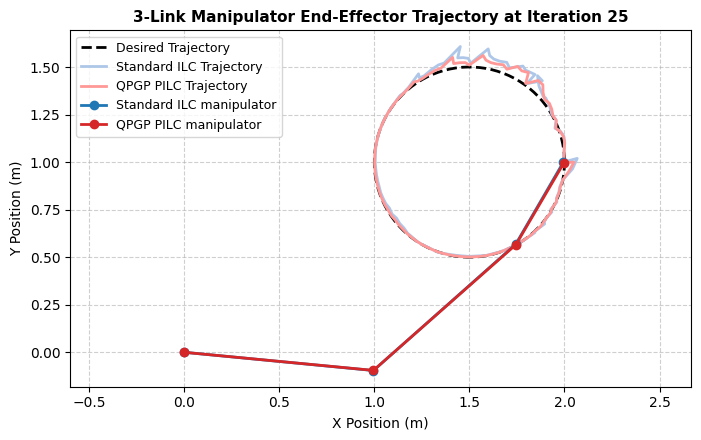

In [8]:
import matplotlib.pyplot as plt
import numpy as np

lap_id = 24  # choose the iteration/lap

# ----------------- Baseline ILC -----------------
joints_b_x, joints_b_y = all_joints_b[lap_id]
joints_b_x_last = joints_b_x[-1, :]
joints_b_y_last = joints_b_y[-1, :]

# ----------------- QPGP ILC -----------------
joints_q_x, joints_q_y = all_joints_q[lap_id]
joints_q_x_last = joints_q_x[-1, :]
joints_q_y_last = joints_q_y[-1, :]

# ----------------- Colors -----------------
arm_color_b = '#1f77b4'  # dark blue for baseline trajectory
arm_color_q = '#d62728'  # dark red for QPGP trajectory
traj_color_b = '#aec7e8'   # light blue for baseline manipulator
traj_color_q = '#ff9896'   # light red for QPGP manipulator

# ----------------- Plot -----------------
fig_width = 7.16
fig_height = 4.5
plt.figure(figsize=(fig_width, fig_height))

# Desired trajectory
plt.plot(x_d, y_d, 'k--', linewidth=2, label='Desired Trajectory')

# End-effector trajectories (darker)
plt.plot(joints_b_x[:, -1], joints_b_y[:, -1], color=traj_color_b, linestyle='-', linewidth=2, label='Standard ILC Trajectory')
plt.plot(joints_q_x[:, -1], joints_q_y[:, -1], color=traj_color_q, linestyle='-', linewidth=2, label='QPGP PILC Trajectory')

# Manipulator links at last point (lighter)
plt.plot(joints_b_x_last, joints_b_y_last, '-o', color=arm_color_b, markersize=6, linewidth=2, label='Standard ILC manipulator')
plt.plot(joints_q_x_last, joints_q_y_last, '-o', color=arm_color_q, markersize=6, linewidth=2, label='QPGP PILC manipulator')

# Labels, grid, legend
plt.xlabel('X Position (m)', fontsize=10)
plt.ylabel('Y Position (m)', fontsize=10)
plt.title(f'3-Link Manipulator End-Effector Trajectory at Iteration {lap_id+1}',
          fontsize=11, fontweight='bold')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=9, loc='best', frameon=True)

plt.tight_layout()
plt.savefig("manipulator_traj.pdf", format='pdf', bbox_inches='tight')
plt.show()


# Midway disturbance

In [9]:
bias_val = 0.1
bias_iter = 49

# ILC params
# Desired trajectory (circle-ish)
n_points = 100
t = np.linspace(0, 2 * np.pi, n_points)
x_d = 1.5 + 0.5 * np.cos(t)
y_d = 1. + 0.5 * np.sin(t)

# Initial bias (unknown dynamics)

s = np.linspace(0, 1, n_points)
b1_s = 0.2 + 0.5*np.sin(8*np.pi*s) + 0.1*np.random.randn(len(s))
b2_s = -0.25 + 0.1*np.cos(6*np.pi*s) + 0.2*np.random.randn(len(s))
b3_s = 0.35 + 0.5*np.exp(-(s-0.04)**2/(2*0.05**2)) + 0.1*np.random.randn(len(s))

# ILC params
n_iter = 100
K = 0.275

x_ee_noise_sd = 0
y_ee_noise_sd = 0

In [ ]:
theta1b_d = np.zeros(n_points)
theta2b_d = np.zeros(n_points)
theta3b_d = np.zeros(n_points)
for i in range(n_points):
    th1, th2, th3 = ik_3link(x_d[i], y_d[i])
    theta1b_d[i] = th1
    theta2b_d[i] = th2
    theta3b_d[i] = th3

baseline_errors = []
all_joints_b = []

theta1b_ff = theta1b_d.copy()
theta2b_ff = theta2b_d.copy()
theta3b_ff = theta3b_d.copy()

for it in range(n_iter):

    # Actual executed joints = feedforward + bias
    theta1b_act = theta1b_ff + b1_s
    theta2b_act = theta2b_ff + b2_s
    theta3b_act = theta3b_ff + b3_s

    if it == bias_iter:
        strong_bias = bias_val # adjust magnitude as needed
        theta1b_act += strong_bias
        theta2b_act += strong_bias
        theta3b_act += strong_bias
        print("Strong bias added")

    # Store joint trajectories
    joints_b_x, joints_b_y = [], []
    for i in range(n_points):
        xj, yj = fk_3link_joints(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        joints_b_x.append(xj)
        joints_b_y.append(yj)
    all_joints_b.append((np.array(joints_b_x), np.array(joints_b_y)))

    # ----- Update in every iteration (from first iter) -----
    for i in range(n_points):
        x_ee, y_ee = fk_ee(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        x_ee = x_ee + np.random.normal(0, x_ee_noise_sd)
        y_ee = y_ee + np.random.normal(0, y_ee_noise_sd)
        e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

        # Jacobian correction
        J = jacobian(theta1b_act[i], theta2b_act[i], theta3b_act[i])
        db_theta = K * J.T @ e

        theta1b_ff[i] += db_theta[0]
        theta2b_ff[i] += db_theta[1]
        theta3b_ff[i] += db_theta[2]

    # Mean error
    ee_positions = np.array([fk_ee(theta1b_act[i], theta2b_act[i], theta3b_act[i]) for i in range(n_points)])
    mean_err_b = np.mean(np.linalg.norm(np.column_stack((x_d, y_d)) - ee_positions, axis=1))
    baseline_errors.append(mean_err_b)

    print(f"Iteration {it+1}/{n_iter} - Baseline: {mean_err_b:.4f}")


Iteration 1/100 - Baseline: 0.9740
Iteration 2/100 - Baseline: 0.5284
Iteration 3/100 - Baseline: 0.4371
Iteration 4/100 - Baseline: 0.3747
Iteration 5/100 - Baseline: 0.3476
Iteration 6/100 - Baseline: 0.3093
Iteration 7/100 - Baseline: 0.2900
Iteration 8/100 - Baseline: 0.2607
Iteration 9/100 - Baseline: 0.2460
Iteration 10/100 - Baseline: 0.2226
Iteration 11/100 - Baseline: 0.2110
Iteration 12/100 - Baseline: 0.1921
Iteration 13/100 - Baseline: 0.1827
Iteration 14/100 - Baseline: 0.1673
Iteration 15/100 - Baseline: 0.1595
Iteration 16/100 - Baseline: 0.1470
Iteration 17/100 - Baseline: 0.1404
Iteration 18/100 - Baseline: 0.1303
Iteration 19/100 - Baseline: 0.1244
Iteration 20/100 - Baseline: 0.1162
Iteration 21/100 - Baseline: 0.1110
Iteration 22/100 - Baseline: 0.1041
Iteration 23/100 - Baseline: 0.0994
Iteration 24/100 - Baseline: 0.0936
Iteration 25/100 - Baseline: 0.0893
Iteration 26/100 - Baseline: 0.0844
Iteration 27/100 - Baseline: 0.0804
Iteration 28/100 - Baseline: 0.0761
I

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore only GP convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---- Initialize desired joint angles ----
theta1q_d, theta2q_d, theta3q_d = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)
for i in range(n_points):
    th1, th2, th3 = ik_3link(x_d[i], y_d[i])
    theta1q_d[i], theta2q_d[i], theta3q_d[i] = th1, th2, th3

Kp = 0.275

qpgp_errors = []
all_joints_q = []

# Initialize feedforward commands same as baseline
theta1q_ff, theta2q_ff, theta3q_ff = theta1q_d.copy(), theta2q_d.copy(), theta3q_d.copy()

# Histories for GP
d_theta1_q_all, d_theta2_q_all, d_theta3_q_all = [], [], []

for it in range(n_iter):

    # Actual executed joints = feedforward + bias
    theta1q_act = theta1q_ff + b1_s
    theta2q_act = theta2q_ff + b2_s
    theta3q_act = theta3q_ff + b3_s

    # ---- Inject strong bias at 5th iteration ----
    if it == bias_iter:
        strong_bias = bias_val  # adjust magnitude as desired
        theta1q_act += strong_bias
        theta2q_act += strong_bias
        theta3q_act += strong_bias
        print("⚠️ Strong bias added")

    # Store joint trajectories
    joints_q_x, joints_q_y = [], []
    for i in range(n_points):
        xj, yj = fk_3link_joints(theta1q_act[i], theta2q_act[i], theta3q_act[i])
        joints_q_x.append(xj)
        joints_q_y.append(yj)
    all_joints_q.append((np.array(joints_q_x), np.array(joints_q_y)))

    # Initialize arrays for this iteration
    d_theta1, d_theta2, d_theta3 = np.zeros(n_points), np.zeros(n_points), np.zeros(n_points)

    # ---- Iteration 0 or 1: baseline only ----
    if it < 1:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee += np.random.normal(0, x_ee_noise_sd)
            y_ee += np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

    # ---- Iteration >= 2: baseline + GP predictive correction ----
    else:
        for i in range(n_points):
            x_ee, y_ee = fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            x_ee += np.random.normal(0, x_ee_noise_sd)
            y_ee += np.random.normal(0, y_ee_noise_sd)
            e = np.array([x_d[i] - x_ee, y_d[i] - y_ee])

            J = jacobian(theta1q_act[i], theta2q_act[i], theta3q_act[i])
            JT = J.T
            d_theta = K * JT @ e

            theta1q_ff[i] += d_theta[0]
            theta2q_ff[i] += d_theta[1]
            theta3q_ff[i] += d_theta[2]

            d_theta1[i] = d_theta[0]
            d_theta2[i] = d_theta[1]
            d_theta3[i] = d_theta[2]

        # ---- Predictive GP correction ----
        if Kp > 0 and len(d_theta1_q_all) > 1:  # at least 2*n_points points
            d1_hist = np.concatenate(d_theta1_q_all)[-2*n_points:]
            d2_hist = np.concatenate(d_theta2_q_all)[-2*n_points:]
            d3_hist = np.concatenate(d_theta3_q_all)[-2*n_points:]

            par1 = par_est(len(d1_hist), [n_points], d1_hist)
            par2 = par_est(len(d2_hist), [n_points], d2_hist)
            par3 = par_est(len(d3_hist), [n_points], d3_hist)

            theta1q_ff += Kp * pred_block(len(d1_hist), n_points, par1['w'], d1_hist)
            theta2q_ff += Kp * pred_block(len(d2_hist), n_points, par2['w'], d2_hist)
            theta3q_ff += Kp * pred_block(len(d3_hist), n_points, par3['w'], d3_hist)

    # ---- Save histories after updates ----
    d_theta1_q_all.append(d_theta1)
    d_theta2_q_all.append(d_theta2)
    d_theta3_q_all.append(d_theta3)

    # Compute mean error for monitoring
    ee_positions = np.array([fk_ee(theta1q_act[i], theta2q_act[i], theta3q_act[i]) for i in range(n_points)])
    mean_err_q = np.mean(np.linalg.norm(np.column_stack((x_d, y_d)) - ee_positions, axis=1))
    qpgp_errors.append(mean_err_q)

    print(f"Iteration {it+1}/{n_iter} - QPGP : {mean_err_q:.4f}")


Iteration 1/100 - QPGP : 0.9740
Iteration 2/100 - QPGP : 0.5284
Iteration 3/100 - QPGP : 0.4371
Iteration 4/100 - QPGP : 0.2339
Iteration 5/100 - QPGP : 0.1883
Iteration 6/100 - QPGP : 0.1980
Iteration 7/100 - QPGP : 0.1524
Iteration 8/100 - QPGP : 0.1069
Iteration 9/100 - QPGP : 0.0946
Iteration 10/100 - QPGP : 0.0860
Iteration 11/100 - QPGP : 0.0709
Iteration 12/100 - QPGP : 0.0584
Iteration 13/100 - QPGP : 0.0517
Iteration 14/100 - QPGP : 0.0456
Iteration 15/100 - QPGP : 0.0396
Iteration 16/100 - QPGP : 0.0349
Iteration 17/100 - QPGP : 0.0312
Iteration 18/100 - QPGP : 0.0278
Iteration 19/100 - QPGP : 0.0249
Iteration 20/100 - QPGP : 0.0225
Iteration 21/100 - QPGP : 0.0203
Iteration 22/100 - QPGP : 0.0184
Iteration 23/100 - QPGP : 0.0167
Iteration 24/100 - QPGP : 0.0153
Iteration 25/100 - QPGP : 0.0140
Iteration 26/100 - QPGP : 0.0128
Iteration 27/100 - QPGP : 0.0118
Iteration 28/100 - QPGP : 0.0108
Iteration 29/100 - QPGP : 0.0100
Iteration 30/100 - QPGP : 0.0092
Iteration 31/100 - 

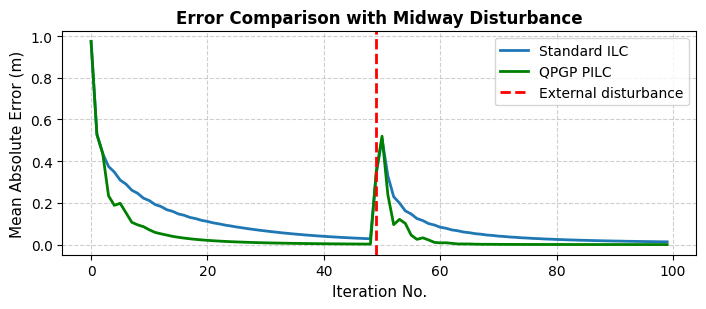

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# IEEE-style figure size (double column)
fig_width = 7.16   # inches
fig_height = 3.2   # inches
plt.figure(figsize=(fig_width, fig_height))

# Plot errors
plt.plot(baseline_errors, linestyle='-', color='C0', linewidth=2, label="Standard ILC")
plt.plot(qpgp_errors, linestyle='-', color='green', linewidth=2, label="QPGP PILC")

# Vertical line for disturbance
plt.axvline(x=bias_iter, color='red', linestyle='--', linewidth=2, label="External disturbance")

# Labels and title
plt.xlabel("Iteration No.", fontsize=11)
plt.ylabel("Mean Absolute Error (m)", fontsize=11)
plt.title("Error Comparison with Midway Disturbance", fontsize=12, fontweight="bold")

# Grid, legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10, loc="best", frameon=True)

# Layout and save
plt.tight_layout()
plt.savefig("manipulator_bias.pdf", format="pdf", bbox_inches="tight")
plt.show()
